# Entrega — BrandonAgent V1 vs V2 con estados iniciales aleatorios

Este notebook evalúa dos versiones del agente `BrandonAgent` para Connect-4:

- **V1 — sin ventanas** (`policy_V1_brandon.py`): gana si puede, bloquea si el rival puede ganar y luego juega por preferencia de columnas centrales.
- **V2 — final con ventanas** (`policy.py`): conserva las reglas tácticas de V1 y agrega una evaluación heurística por ventanas de 4 casillas.

El objetivo principal de esta versión del notebook es evitar que la comparación directa sea una repetición de la misma partida determinista. Para eso, se agregan **estados iniciales variados**: antes de que los agentes empiecen a decidir, el simulador coloca aleatoriamente la primera ficha roja en una columna legal.

Con esto, la comparación directa V1 vs V2 se evalúa desde diferentes tableros iniciales.


## 1. Importación de librerías

In [56]:
import sys
import time
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

print("Librerías cargadas correctamente.")
BG_COLOR = "#E7EDED"

plt.rcParams["figure.facecolor"] = BG_COLOR
plt.rcParams["axes.facecolor"] = BG_COLOR
plt.rcParams["savefig.facecolor"] = BG_COLOR


Librerías cargadas correctamente.


## 2. Configuración automática de rutas

El notebook está pensado para ejecutarse desde:

```text
AI-Final-Project/tournament/groups/Group B/
```

También intenta encontrar automáticamente la raíz de `tournament` si se ejecuta desde otra carpeta.


In [57]:
def find_tournament_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start] + list(start.parents)

    for p in candidates:
        if (p / "connect4").exists():
            return p
        if (p / "tournament" / "connect4").exists():
            return p / "tournament"

    raise FileNotFoundError(
        "No se encontró la carpeta tournament/connect4. "
        "Ejecuta este notebook desde la carpeta del proyecto o desde tournament/groups/Group B."
    )

CURRENT_DIR = Path.cwd().resolve()
TOURNAMENT_ROOT = find_tournament_root(CURRENT_DIR)

if (CURRENT_DIR / "policy.py").exists():
    GROUP_DIR = CURRENT_DIR
else:
    GROUP_DIR = TOURNAMENT_ROOT / "groups" / "Group B"

sys.path.insert(0, str(TOURNAMENT_ROOT))

print("CURRENT_DIR:", CURRENT_DIR)
print("TOURNAMENT_ROOT:", TOURNAMENT_ROOT)
print("GROUP_DIR:", GROUP_DIR)
print("Archivos detectados:", [p.name for p in GROUP_DIR.iterdir() if p.is_file()])


CURRENT_DIR: /Users/merchito/Documents/Computer Engineering/7th Semester/Fundamentos IA/Proyecto final/AI-Final-Project/tournament/groups/Group B
TOURNAMENT_ROOT: /Users/merchito/Documents/Computer Engineering/7th Semester/Fundamentos IA/Proyecto final/AI-Final-Project/tournament
GROUP_DIR: /Users/merchito/Documents/Computer Engineering/7th Semester/Fundamentos IA/Proyecto final/AI-Final-Project/tournament/groups/Group B
Archivos detectados: ['.DS_Store', 'policy.py', 'entrega.ipynb', 'readme.md', 'policy_V1_brandon.py']


## 3. Carga de agentes

Archivos esperados:

```text
policy_V1_brandon.py   # V1 sin ventanas
policy.py              # V2 final con ventanas
```

Ambos archivos deben contener una clase llamada `BrandonAgent`.


In [58]:
V1_FILE = "policy_V1_brandon.py"
V2_FILE = "policy.py"

def load_agent_class(file_path: Path, module_name: str):
    if not file_path.exists():
        raise FileNotFoundError(f"No existe el archivo: {file_path}")

    spec = importlib.util.spec_from_file_location(module_name, str(file_path))
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)

    if not hasattr(module, "BrandonAgent"):
        raise AttributeError(f"El archivo {file_path.name} no tiene una clase BrandonAgent.")

    return module.BrandonAgent

V1Agent = load_agent_class(GROUP_DIR / V1_FILE, "brandon_v1_module")
V2Agent = load_agent_class(GROUP_DIR / V2_FILE, "brandon_v2_module")

print("Agentes cargados correctamente:")
print("V1 sin ventanas:", V1Agent)
print("V2 con ventanas:", V2Agent)


Agentes cargados correctamente:
V1 sin ventanas: <class 'brandon_v1_module.BrandonAgent'>
V2 con ventanas: <class 'brandon_v2_module.BrandonAgent'>


## 4. Simulador local de Connect-4

Convención usada por el agente:

```text
0  = celda vacía
-1 = rojo
1  = amarillo
```

La función `play_game` permite iniciar desde tablero vacío o desde un tablero con movimientos aleatorios previos.


In [59]:
ROWS = 6
COLS = 7
EMPTY = 0
RED = -1
YELLOW = 1
MAX_MOVES = ROWS * COLS

def legal_actions(board: np.ndarray):
    return [c for c in range(COLS) if board[0, c] == EMPTY]

def drop_piece_inplace(board: np.ndarray, col: int, piece: int):
    for row in range(ROWS - 1, -1, -1):
        if board[row, col] == EMPTY:
            board[row, col] = piece
            return row
    raise ValueError(f"Columna llena: {col}")

def has_four(board: np.ndarray, piece: int) -> bool:
    directions = [
        (0, 1),    # horizontal
        (1, 0),    # vertical
        (1, 1),    # diagonal \
        (1, -1),   # diagonal /
    ]

    for row in range(ROWS):
        for col in range(COLS):
            if board[row, col] != piece:
                continue

            for dr, dc in directions:
                count = 0
                for k in range(4):
                    r = row + dr * k
                    c = col + dc * k

                    if 0 <= r < ROWS and 0 <= c < COLS and board[r, c] == piece:
                        count += 1
                    else:
                        break

                if count == 4:
                    return True

    return False

def current_player(board: np.ndarray) -> int:
    red_count = int(np.sum(board == RED))
    yellow_count = int(np.sum(board == YELLOW))
    return RED if red_count == yellow_count else YELLOW

class RandomAgent:
    def __init__(self, seed=None):
        self.rng = np.random.default_rng(seed)

    def mount(self, timeout=None):
        pass

    def act(self, s: np.ndarray) -> int:
        actions = legal_actions(s)
        return int(self.rng.choice(actions))

def make_random_agent(seed):
    class SeededRandomAgent(RandomAgent):
        def __init__(self):
            super().__init__(seed=seed)
    return SeededRandomAgent


## 5. Estados iniciales aleatorios

Esta función coloca `n_opening_moves` movimientos aleatorios antes de que los agentes empiecen a jugar.

Para este análisis usaremos principalmente:

```python
n_opening_moves = 1
```

Eso significa que el tablero inicia con una ficha roja aleatoria, y luego le toca jugar al amarillo.


In [60]:
def apply_random_opening(board: np.ndarray, n_opening_moves: int, rng: np.random.Generator):
    opening_cols = []

    for _ in range(n_opening_moves):
        actions = legal_actions(board)
        if not actions:
            break

        piece = current_player(board)
        col = int(rng.choice(actions))
        drop_piece_inplace(board, col, piece)
        opening_cols.append(col)

        # Por seguridad, si el movimiento aleatorio produjera victoria, se detiene.
        # Con 1 movimiento esto no puede pasar, pero se deja general.
        if has_four(board, piece):
            break

    return opening_cols


## 6. Función para jugar una partida

Parámetros importantes:

- `seed`: controla la aleatoriedad del estado inicial.
- `n_opening_moves`: número de movimientos aleatorios antes de que empiecen los agentes.


In [61]:
def play_game(red_agent_cls, yellow_agent_cls, seed=0, n_opening_moves=0, timeout=None):
    rng = np.random.default_rng(seed)
    board = np.zeros((ROWS, COLS), dtype=int)

    opening_cols = apply_random_opening(board, n_opening_moves=n_opening_moves, rng=rng)

    red_agent = red_agent_cls()
    yellow_agent = yellow_agent_cls()

    if hasattr(red_agent, "mount"):
        red_agent.mount(timeout=timeout)
    if hasattr(yellow_agent, "mount"):
        yellow_agent.mount(timeout=timeout)

    times = []
    initial_moves = len(opening_cols)

    for move_idx in range(initial_moves, MAX_MOVES):
        piece = current_player(board)
        agent = red_agent if piece == RED else yellow_agent

        start = time.perf_counter()
        try:
            col = int(agent.act(board.copy()))
        except Exception as e:
            return {
                "winner": -piece,
                "moves": move_idx + 1,
                "draw": False,
                "invalid_move": True,
                "invalid_player": piece,
                "error": repr(e),
                "avg_time_per_move_ms": float(np.mean(times) * 1000) if times else 0.0,
                "opening_cols": opening_cols,
                "opening_first_col": opening_cols[0] if opening_cols else None,
            }

        elapsed = time.perf_counter() - start
        times.append(elapsed)

        if col not in legal_actions(board):
            return {
                "winner": -piece,
                "moves": move_idx + 1,
                "draw": False,
                "invalid_move": True,
                "invalid_player": piece,
                "error": f"Invalid column: {col}",
                "avg_time_per_move_ms": float(np.mean(times) * 1000),
                "opening_cols": opening_cols,
                "opening_first_col": opening_cols[0] if opening_cols else None,
            }

        drop_piece_inplace(board, col, piece)

        if has_four(board, piece):
            return {
                "winner": piece,
                "moves": move_idx + 1,
                "draw": False,
                "invalid_move": False,
                "invalid_player": None,
                "error": None,
                "avg_time_per_move_ms": float(np.mean(times) * 1000),
                "opening_cols": opening_cols,
                "opening_first_col": opening_cols[0] if opening_cols else None,
            }

    return {
        "winner": 0,
        "moves": MAX_MOVES,
        "draw": True,
        "invalid_move": False,
        "invalid_player": None,
        "error": None,
        "avg_time_per_move_ms": float(np.mean(times) * 1000) if times else 0.0,
        "opening_cols": opening_cols,
        "opening_first_col": opening_cols[0] if opening_cols else None,
    }


## 7. Experimento A — comparación directa desde tablero vacío

Este experimento se conserva como línea base. Como ambos agentes son deterministas, repetir partidas desde el tablero vacío puede producir la misma trayectoria.


In [62]:
def evaluate_direct_v1_vs_v2(n_games=100, base_seed=6000, n_opening_moves=0):
    rows = []

    for i in range(n_games):
        seed = base_seed + i

        # Caso 1: V2 es rojo, V1 es amarillo
        result = play_game(
            red_agent_cls=V2Agent,
            yellow_agent_cls=V1Agent,
            seed=seed,
            n_opening_moves=n_opening_moves,
        )

        rows.append({
            "game": i,
            "matchup": "V2_RED_vs_V1_YELLOW",
            "v2_color": "RED",
            "v1_color": "YELLOW",
            "opening_moves": n_opening_moves,
            "opening_first_col": result["opening_first_col"],
            "winner": result["winner"],
            "v2_won": result["winner"] == RED,
            "v1_won": result["winner"] == YELLOW,
            "draw": result["draw"],
            "moves": result["moves"],
            "invalid_move": result["invalid_move"],
            "error": result["error"],
            "avg_time_per_move_ms": result["avg_time_per_move_ms"],
        })

        # Caso 2: V1 es rojo, V2 es amarillo
        result = play_game(
            red_agent_cls=V1Agent,
            yellow_agent_cls=V2Agent,
            seed=seed + 10_000,
            n_opening_moves=n_opening_moves,
        )

        rows.append({
            "game": i,
            "matchup": "V1_RED_vs_V2_YELLOW",
            "v2_color": "YELLOW",
            "v1_color": "RED",
            "opening_moves": n_opening_moves,
            "opening_first_col": result["opening_first_col"],
            "winner": result["winner"],
            "v2_won": result["winner"] == YELLOW,
            "v1_won": result["winner"] == RED,
            "draw": result["draw"],
            "moves": result["moves"],
            "invalid_move": result["invalid_move"],
            "error": result["error"],
            "avg_time_per_move_ms": result["avg_time_per_move_ms"],
        })

    return pd.DataFrame(rows)

empty_direct_df = evaluate_direct_v1_vs_v2(n_games=100, base_seed=6000, n_opening_moves=0)

empty_direct_summary = empty_direct_df.groupby("matchup").agg(
    n_games=("game", "count"),
    v2_win_rate=("v2_won", "mean"),
    v1_win_rate=("v1_won", "mean"),
    draw_rate=("draw", "mean"),
    avg_moves=("moves", "mean"),
    avg_time_per_move_ms=("avg_time_per_move_ms", "mean"),
    invalid_moves=("invalid_move", "sum"),
).reset_index()

empty_direct_summary


,matchup,n_games,v2_win_rate,v1_win_rate,draw_rate,avg_moves,avg_time_per_move_ms,invalid_moves
0,V1_RED_vs_V2_YELLOW,100,1.0,0.0,0.0,26.0,0.720868,0
1,V2_RED_vs_V1_YELLOW,100,1.0,0.0,0.0,7.0,0.655678,0


## 8. Experimento B — comparación directa con primera ficha aleatoria

Este es el experimento más importante de este notebook.

Ahora cada partida inicia con una ficha roja colocada aleatoriamente en una columna legal. Después de esa apertura, los agentes juegan normalmente.

Esto genera distintos estados iniciales y permite analizar mejor la diferencia entre V1 y V2.


In [63]:
N_RANDOM_INITIAL_GAMES = 300
RANDOM_OPENING_MOVES = 1

random_initial_df = evaluate_direct_v1_vs_v2(
    n_games=N_RANDOM_INITIAL_GAMES,
    base_seed=8000,
    n_opening_moves=RANDOM_OPENING_MOVES,
)

random_initial_summary = random_initial_df.groupby("matchup").agg(
    n_games=("game", "count"),
    v2_win_rate=("v2_won", "mean"),
    v1_win_rate=("v1_won", "mean"),
    draw_rate=("draw", "mean"),
    avg_moves=("moves", "mean"),
    avg_time_per_move_ms=("avg_time_per_move_ms", "mean"),
    invalid_moves=("invalid_move", "sum"),
).reset_index()

random_initial_summary


,matchup,n_games,v2_win_rate,v1_win_rate,draw_rate,avg_moves,avg_time_per_move_ms,invalid_moves
0,V1_RED_vs_V2_YELLOW,300,1.000000,0.000000,0.0,15.753333,0.749669,0
1,V2_RED_vs_V1_YELLOW,300,0.746667,0.253333,0.0,21.633333,0.743733,0


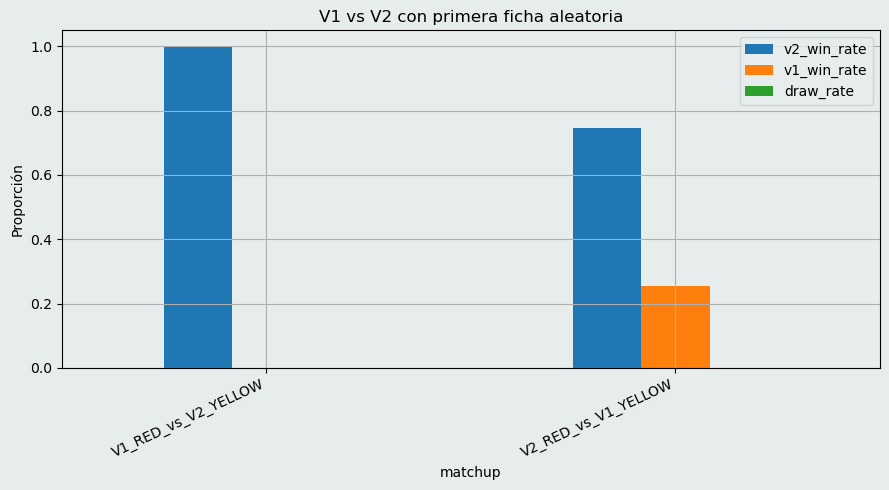

In [64]:
# Gráfica 1: comparación directa con primera ficha aleatoria
plot_direct = random_initial_summary.set_index("matchup")[["v2_win_rate", "v1_win_rate", "draw_rate"]]

ax = plot_direct.plot(kind="bar")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Proporción")
ax.set_title("V1 vs V2 con primera ficha aleatoria")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


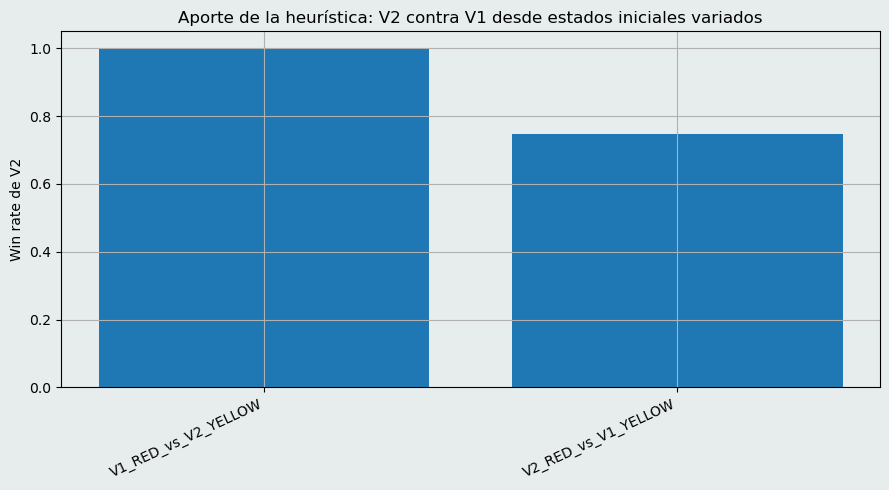

In [65]:
# Gráfica 2: win rate de V2 con primera ficha aleatoria
fig, ax = plt.subplots()

x = np.arange(len(random_initial_summary))
ax.bar(x, random_initial_summary["v2_win_rate"])

ax.set_xticks(x)
ax.set_xticklabels(random_initial_summary["matchup"], rotation=25, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Win rate de V2")
ax.set_title("Aporte de la heurística: V2 contra V1 desde estados iniciales variados")

plt.tight_layout()
plt.show()


## 9. Análisis por columna inicial

Como el estado inicial tiene una primera ficha roja aleatoria, también se puede analizar si la columna inicial cambia el resultado.


In [66]:
by_opening_col = random_initial_df.groupby(["matchup", "opening_first_col"]).agg(
    n_games=("game", "count"),
    v2_win_rate=("v2_won", "mean"),
    v1_win_rate=("v1_won", "mean"),
    draw_rate=("draw", "mean"),
    avg_moves=("moves", "mean"),
).reset_index()

by_opening_col


,matchup,opening_first_col,n_games,v2_win_rate,v1_win_rate,draw_rate,avg_moves
0,V1_RED_vs_V2_YELLOW,0,47,1.0,0.0,0.0,8.0
1,V1_RED_vs_V2_YELLOW,1,47,1.0,0.0,0.0,8.0
2,V1_RED_vs_V2_YELLOW,2,29,1.0,0.0,0.0,22.0
3,V1_RED_vs_V2_YELLOW,3,44,1.0,0.0,0.0,26.0
4,V1_RED_vs_V2_YELLOW,4,47,1.0,0.0,0.0,32.0
5,V1_RED_vs_V2_YELLOW,5,46,1.0,0.0,0.0,8.0
6,V1_RED_vs_V2_YELLOW,6,40,1.0,0.0,0.0,8.0
7,V2_RED_vs_V1_YELLOW,0,45,1.0,0.0,0.0,23.0
8,V2_RED_vs_V1_YELLOW,1,40,1.0,0.0,0.0,23.0
9,V2_RED_vs_V1_YELLOW,2,41,0.0,1.0,0.0,22.0


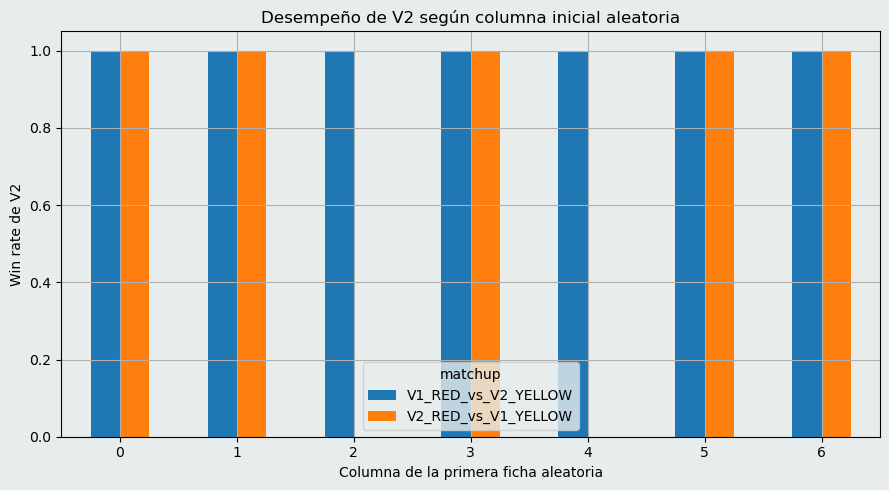

In [67]:
# Gráfica 3: V2 win rate por columna inicial
pivot_v2 = by_opening_col.pivot(
    index="opening_first_col",
    columns="matchup",
    values="v2_win_rate"
).sort_index()

ax = pivot_v2.plot(kind="bar")
ax.set_ylim(0, 1.05)
ax.set_xlabel("Columna de la primera ficha aleatoria")
ax.set_ylabel("Win rate de V2")
ax.set_title("Desempeño de V2 según columna inicial aleatoria")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 10. Experimento C — comparación contra agente aleatorio

Se conserva esta evaluación porque el reto pide evidencia frente al agente aleatorio.  
Aquí también se usa primera ficha aleatoria para hacer las partidas menos repetitivas.


In [68]:
def evaluate_vs_random(agent_cls, agent_label, agent_color, n_games=100, base_seed=1000, n_opening_moves=1):
    rows = []

    for i in range(n_games):
        seed = base_seed + i

        if agent_color == RED:
            result = play_game(
                red_agent_cls=agent_cls,
                yellow_agent_cls=make_random_agent(seed + 50_000),
                seed=seed,
                n_opening_moves=n_opening_moves,
            )
        elif agent_color == YELLOW:
            result = play_game(
                red_agent_cls=make_random_agent(seed + 50_000),
                yellow_agent_cls=agent_cls,
                seed=seed,
                n_opening_moves=n_opening_moves,
            )
        else:
            raise ValueError("agent_color debe ser RED o YELLOW.")

        rows.append({
            "game": i,
            "agent": agent_label,
            "agent_color": "RED" if agent_color == RED else "YELLOW",
            "opening_moves": n_opening_moves,
            "opening_first_col": result["opening_first_col"],
            "winner": result["winner"],
            "agent_won": result["winner"] == agent_color,
            "agent_lost": result["winner"] == -agent_color,
            "draw": result["draw"],
            "moves": result["moves"],
            "invalid_move": result["invalid_move"],
            "error": result["error"],
            "avg_time_per_move_ms": result["avg_time_per_move_ms"],
        })

    return pd.DataFrame(rows)

random_dfs = []
N_RANDOM_GAMES = 100

for agent_label, agent_cls in [
    ("V1_sin_ventanas", V1Agent),
    ("V2_con_ventanas", V2Agent),
]:
    random_dfs.append(evaluate_vs_random(agent_cls, agent_label, RED, n_games=N_RANDOM_GAMES, base_seed=11000, n_opening_moves=1))
    random_dfs.append(evaluate_vs_random(agent_cls, agent_label, YELLOW, n_games=N_RANDOM_GAMES, base_seed=12000, n_opening_moves=1))

random_df = pd.concat(random_dfs, ignore_index=True)

random_summary = random_df.groupby(["agent", "agent_color"]).agg(
    n_games=("game", "count"),
    win_rate=("agent_won", "mean"),
    loss_rate=("agent_lost", "mean"),
    draw_rate=("draw", "mean"),
    avg_moves=("moves", "mean"),
    avg_time_per_move_ms=("avg_time_per_move_ms", "mean"),
    invalid_moves=("invalid_move", "sum"),
).reset_index()

random_summary


,agent,agent_color,n_games,win_rate,loss_rate,draw_rate,avg_moves,avg_time_per_move_ms,invalid_moves
0,V1_sin_ventanas,RED,100,1.00,0.00,0.0,12.04,0.113040,0
1,V1_sin_ventanas,YELLOW,100,0.98,0.02,0.0,12.24,0.092059,0
2,V2_con_ventanas,RED,100,1.00,0.00,0.0,8.68,0.522474,0
3,V2_con_ventanas,YELLOW,100,1.00,0.00,0.0,10.48,0.723979,0


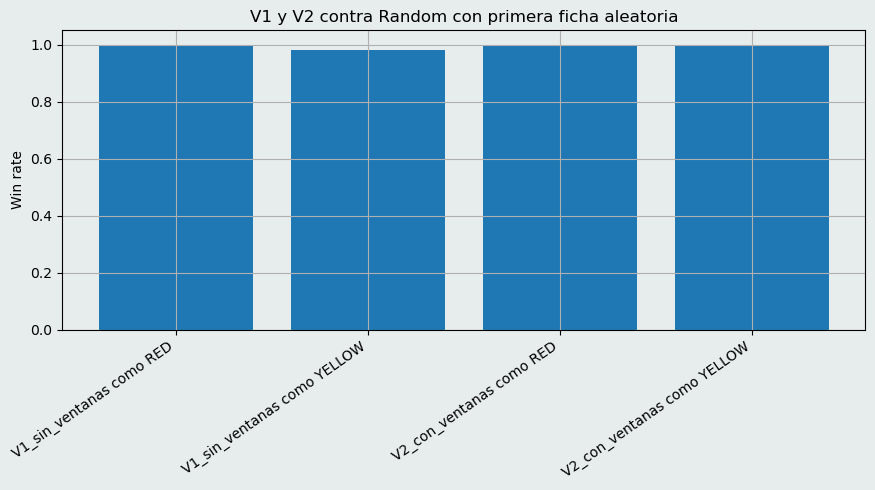

In [69]:
# Gráfica 4: V1 y V2 contra Random con primera ficha aleatoria
random_plot = random_summary.copy()
random_plot["label"] = random_plot["agent"] + " como " + random_plot["agent_color"]

fig, ax = plt.subplots()
x = np.arange(len(random_plot))
ax.bar(x, random_plot["win_rate"])

ax.set_xticks(x)
ax.set_xticklabels(random_plot["label"], rotation=35, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Win rate")
ax.set_title("V1 y V2 contra Random con primera ficha aleatoria")

plt.tight_layout()
plt.show()


## 11. Experimento D — auto-desempeño de V2 con primera ficha aleatoria

Se evalúa V2 contra sí mismo desde estados iniciales variados.


In [70]:
def evaluate_self_play(agent_cls, label="V2_self_play", n_games=100, base_seed=13000, n_opening_moves=1):
    rows = []

    for i in range(n_games):
        seed = base_seed + i
        result = play_game(
            red_agent_cls=agent_cls,
            yellow_agent_cls=agent_cls,
            seed=seed,
            n_opening_moves=n_opening_moves,
        )

        rows.append({
            "game": i,
            "experiment": label,
            "opening_moves": n_opening_moves,
            "opening_first_col": result["opening_first_col"],
            "winner": result["winner"],
            "red_won": result["winner"] == RED,
            "yellow_won": result["winner"] == YELLOW,
            "draw": result["draw"],
            "moves": result["moves"],
            "invalid_move": result["invalid_move"],
            "error": result["error"],
            "avg_time_per_move_ms": result["avg_time_per_move_ms"],
        })

    return pd.DataFrame(rows)

selfplay_df = evaluate_self_play(V2Agent, n_games=100, n_opening_moves=1)

selfplay_summary = pd.DataFrame([{
    "experiment": "V2_self_play_random_initial",
    "n_games": len(selfplay_df),
    "red_win_rate": selfplay_df["red_won"].mean(),
    "yellow_win_rate": selfplay_df["yellow_won"].mean(),
    "draw_rate": selfplay_df["draw"].mean(),
    "avg_moves": selfplay_df["moves"].mean(),
    "avg_time_per_move_ms": selfplay_df["avg_time_per_move_ms"].mean(),
    "invalid_moves": int(selfplay_df["invalid_move"].sum()),
}])

selfplay_summary


,experiment,n_games,red_win_rate,yellow_win_rate,draw_rate,avg_moves,avg_time_per_move_ms,invalid_moves
0,V2_self_play_random_initial,100,0.0,0.87,0.13,30.16,1.43914,0


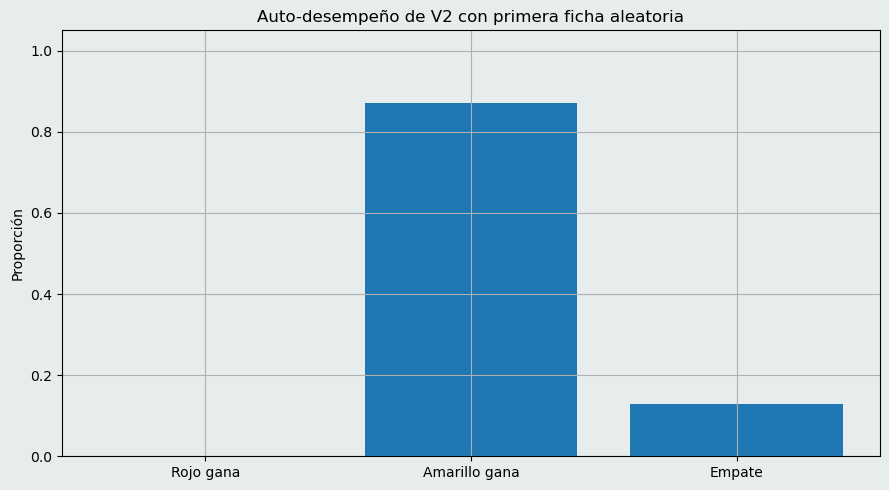

In [71]:
# Gráfica 5: self-play V2 con primera ficha aleatoria
labels = ["Rojo gana", "Amarillo gana", "Empate"]
values = [
    selfplay_df["red_won"].mean(),
    selfplay_df["yellow_won"].mean(),
    selfplay_df["draw"].mean(),
]

fig, ax = plt.subplots()
ax.bar(labels, values)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Proporción")
ax.set_title("Auto-desempeño de V2 con primera ficha aleatoria")
plt.tight_layout()
plt.show()


## 12. Experimento E — variable numérica: peso del centro

Se varía el peso de la bonificación por controlar el centro en V2.  
Este análisis sirve como variable numérica de configuración.


In [72]:
class WeightedCenterAgent(V2Agent):
    CENTER_WEIGHT = 6

    def score_position(self, board: np.ndarray, me: int, opp: int) -> int:
        score = 0

        center_col = board[:, self.COLS // 2]
        center_count = int(np.sum(center_col == me))
        score += center_count * self.CENTER_WEIGHT

        # ventanas horizontales
        for row in range(self.ROWS):
            for col in range(self.COLS - 3):
                window = list(board[row, col:col + 4])
                score += self.evaluate_window(window, me, opp)

        # ventanas verticales
        for col in range(self.COLS):
            for row in range(self.ROWS - 3):
                window = list(board[row:row + 4, col])
                score += self.evaluate_window(window, me, opp)

        # ventanas diagonales \
        for row in range(self.ROWS - 3):
            for col in range(self.COLS - 3):
                window = [board[row + i, col + i] for i in range(4)]
                score += self.evaluate_window(window, me, opp)

        # ventanas diagonales /
        for row in range(3, self.ROWS):
            for col in range(self.COLS - 3):
                window = [board[row - i, col + i] for i in range(4)]
                score += self.evaluate_window(window, me, opp)

        return score

def make_weighted_center_agent(center_weight):
    class AgentWithWeight(WeightedCenterAgent):
        CENTER_WEIGHT = center_weight
    AgentWithWeight.__name__ = f"V2WeightedCenter_{center_weight}"
    return AgentWithWeight

weights = [0, 3, 6, 9, 12]
weight_results = []

for w in weights:
    AgentW = make_weighted_center_agent(w)

    df_red = evaluate_vs_random(
        agent_cls=AgentW,
        agent_label=f"V2_center_weight_{w}",
        agent_color=RED,
        n_games=50,
        base_seed=14000 + w,
        n_opening_moves=1,
    )

    df_yellow = evaluate_vs_random(
        agent_cls=AgentW,
        agent_label=f"V2_center_weight_{w}",
        agent_color=YELLOW,
        n_games=50,
        base_seed=15000 + w,
        n_opening_moves=1,
    )

    combined = pd.concat([df_red, df_yellow], ignore_index=True)

    weight_results.append({
        "center_weight": w,
        "win_rate": combined["agent_won"].mean(),
        "loss_rate": combined["agent_lost"].mean(),
        "draw_rate": combined["draw"].mean(),
        "avg_moves": combined["moves"].mean(),
        "avg_time_per_move_ms": combined["avg_time_per_move_ms"].mean(),
        "invalid_moves": int(combined["invalid_move"].sum()),
    })

weight_df = pd.DataFrame(weight_results)
weight_df


,center_weight,win_rate,loss_rate,draw_rate,avg_moves,avg_time_per_move_ms,invalid_moves
0,0,1.0,0.0,0.0,10.10,0.589040,0
1,3,1.0,0.0,0.0,9.98,0.577491,0
2,6,1.0,0.0,0.0,9.98,0.614418,0
3,9,1.0,0.0,0.0,9.84,0.581750,0
4,12,1.0,0.0,0.0,9.66,0.572223,0


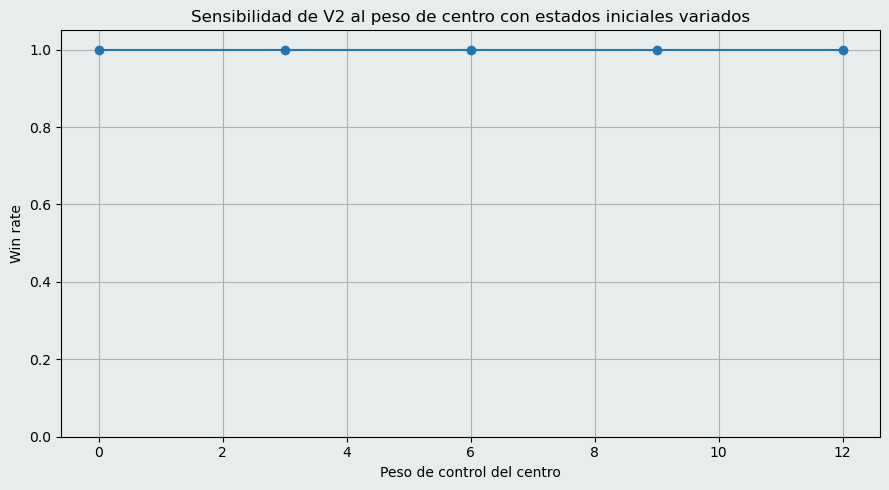

In [73]:
# Gráfica 6: sensibilidad al peso de centro con primera ficha aleatoria
fig, ax = plt.subplots()
ax.plot(weight_df["center_weight"], weight_df["win_rate"], marker="o")

ax.set_ylim(0, 1.05)
ax.set_xlabel("Peso de control del centro")
ax.set_ylabel("Win rate")
ax.set_title("Sensibilidad de V2 al peso de centro con estados iniciales variados")

plt.tight_layout()
plt.show()


## 13. Resumen final para PDF y presentación

In [74]:
print("A. Comparación directa desde tablero vacío")
display(empty_direct_summary)

print("B. Comparación directa con primera ficha aleatoria")
display(random_initial_summary)

print("C. Análisis por columna inicial")
display(by_opening_col)

print("D. Comparación contra Random con primera ficha aleatoria")
display(random_summary)

print("E. Self-play V2 con primera ficha aleatoria")
display(selfplay_summary)

print("F. Sensibilidad al peso de centro")
display(weight_df)


A. Comparación directa desde tablero vacío


,matchup,n_games,v2_win_rate,v1_win_rate,draw_rate,avg_moves,avg_time_per_move_ms,invalid_moves
0,V1_RED_vs_V2_YELLOW,100,1.0,0.0,0.0,26.0,0.720868,0
1,V2_RED_vs_V1_YELLOW,100,1.0,0.0,0.0,7.0,0.655678,0


B. Comparación directa con primera ficha aleatoria


,matchup,n_games,v2_win_rate,v1_win_rate,draw_rate,avg_moves,avg_time_per_move_ms,invalid_moves
0,V1_RED_vs_V2_YELLOW,300,1.000000,0.000000,0.0,15.753333,0.749669,0
1,V2_RED_vs_V1_YELLOW,300,0.746667,0.253333,0.0,21.633333,0.743733,0


C. Análisis por columna inicial


...

,agent,agent_color,n_games,win_rate,loss_rate,draw_rate,avg_moves,avg_time_per_move_ms,invalid_moves
0,V1_sin_ventanas,RED,100,1.00,0.00,0.0,12.04,0.113040,0
1,V1_sin_ventanas,YELLOW,100,0.98,0.02,0.0,12.24,0.092059,0
2,V2_con_ventanas,RED,100,1.00,0.00,0.0,8.68,0.522474,0
3,V2_con_ventanas,YELLOW,100,1.00,0.00,0.0,10.48,0.723979,0


E. Self-play V2 con primera ficha aleatoria


,experiment,n_games,red_win_rate,yellow_win_rate,draw_rate,avg_moves,avg_time_per_move_ms,invalid_moves
0,V2_self_play_random_initial,100,0.0,0.87,0.13,30.16,1.43914,0


F. Sensibilidad al peso de centro


,center_weight,win_rate,loss_rate,draw_rate,avg_moves,avg_time_per_move_ms,invalid_moves
0,0,1.0,0.0,0.0,10.10,0.589040,0
1,3,1.0,0.0,0.0,9.98,0.577491,0
2,6,1.0,0.0,0.0,9.98,0.614418,0
3,9,1.0,0.0,0.0,9.84,0.581750,0
4,12,1.0,0.0,0.0,9.66,0.572223,0


## Conclusiones del análisis experimental

La comparación entre V1 y V2 muestra que la heurística de ventanas sí aporta valor, especialmente cuando el análisis se realiza desde estados iniciales variados. Desde tablero vacío, V2 gana el 100% de las partidas contra V1 en ambos roles de color; sin embargo, esta evidencia es limitada porque ambos agentes son deterministas y tienden a repetir la misma secuencia de jugadas.

Para evitar ese sesgo, se evaluaron partidas con una primera ficha roja aleatoria. En ese escenario, V2 mantiene superioridad general sobre V1. Cuando V2 juega como amarillo contra V1 rojo, alcanza un win rate de 100%. Cuando V2 juega como rojo contra V1 amarillo, obtiene un win rate de 74.67%, mientras V1 gana el 25.33%. Esto evidencia que la heurística mejora el rendimiento, pero también muestra que el desempeño depende del color y del estado inicial.

El análisis por columna inicial revela una debilidad específica: cuando la primera ficha aleatoria queda en ciertas columnas, especialmente las columnas 2 y 4 en el caso V2 rojo vs V1 amarillo, V1 logra explotar la posición y ganar. Esto indica que V2 no domina todos los estados iniciales y que su heurística todavía puede ser vulnerable ante configuraciones tempranas específicas.

Contra el agente aleatorio, ambas versiones tienen desempeño muy alto. V1 gana 100% como rojo y 98% como amarillo, mientras que V2 gana 100% en ambos colores. Esto confirma que ambas versiones cumplen el requisito mínimo frente al aleatorio, pero también muestra un efecto techo: el oponente aleatorio es demasiado débil para diferenciar claramente las versiones. La comparación directa V1 vs V2 es más informativa.

Además, V2 gana en menos movimientos promedio contra Random: como rojo reduce el promedio de 12.04 movimientos en V1 a 8.68 movimientos, y como amarillo reduce de 12.24 a 10.48 movimientos. Por tanto, V2 no solo mejora la tasa de victoria, sino también la eficiencia de cierre de partidas.

En self-play, V2 contra sí mismo con primera ficha aleatoria muestra 87% de victorias para amarillo y 13% de empates. Esto sugiere que, bajo esta configuración experimental, el turno posterior a la apertura aleatoria puede favorecer al jugador amarillo. También muestra que el agente es estable, ya que no presenta movimientos inválidos.

Finalmente, al variar el peso de control del centro, el win rate contra Random se mantiene en 100% para todos los valores evaluados. Esto confirma nuevamente el efecto techo contra Random. Sin embargo, el número promedio de movimientos sí cambia ligeramente, pasando de 10.10 movimientos con peso 0 a 9.66 con peso 12. Esto sugiere que el peso del centro afecta más la eficiencia que la victoria cuando el oponente es débil.

En conclusión, V2 mejora a V1 porque agrega una evaluación posicional por ventanas de cuatro casillas, permitiendo tomar mejores decisiones cuando no existe una victoria o bloqueo inmediato. La principal limitación observada es que V2 no realiza búsqueda profunda: solo evalúa el estado resultante de una jugada propia y revisa si regala una victoria inmediata al rival. Como mejora futura, sería razonable incorporar Minimax con poda Alpha-Beta, MCTS o detección explícita de amenazas dobles.